# Random Forests
Credit: [In-Depth: Decision Trees and Random Forests](https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.08-Random-Forests.ipynb#scrollTo=IO96x1TFqwKI)

Here we'll take a look at motivating another powerful algorithm—a non-parametric algorithm called *random forests*.


Random forests are an example of an *ensemble* method, meaning that it relies on aggregating the results of an ensemble of simpler estimators.

The somewhat surprising result with such ensemble methods is that the sum can be greater than the parts: that is, a majority vote among a number of estimators can end up being better than any of the individual estimators doing the voting!
We will see examples of this in the following sections.
We begin with the standard imports:

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Ensembles of Estimators: Random Forests

This notion—that multiple overfitting estimators can be combined **to reduce the effect of this overfitting** — is what underlies an ensemble method called *bagging*.
Bagging makes use of an ensemble (a grab bag, perhaps) of parallel estimators, each of which over-fits the data, and averages the results to find a better classification.
An ensemble of randomized decision trees is known as a *random forest*.

![](https://miro.medium.com/max/658/1*VHDtVaDPNepRglIAv72BFg.jpeg)


**Bagging (Bootstrap Aggregation)** — Decisions trees are very sensitive to the data they are trained on — small changes to the training set can result in significantly different tree structures. Random forest takes advantage of this by allowing each individual tree to randomly sample from the dataset with replacement, resulting in different trees. This process is known as bagging.

Credit: [Understanding Random Forest](https://towardsdatascience.com/understanding-random-forest-58381e0602d2#:~:text=The%20random%20forest%20is%20a,that%20of%20any%20individual%20tree.)

![](https://ars.els-cdn.com/content/image/3-s2.0-B9780128177365000090-f09-17-9780128177365.jpg)

Notice that with **bagging** we are not subsetting the training data into smaller chunks and training each tree on a different chunk. Rather, if we have a sample of size N, we are still feeding each tree a training set of size N (unless specified otherwise). But instead of the original training data, we take **a random sample of size N with replacement**.

**Feature Randomness** — In a normal decision tree, when it is time to split a node, we consider every possible feature and pick the one that produces the most separation between the observations in the left node vs. those in the right node. In contrast, each tree in a random forest can pick only from a random subset of features. This forces even more variation amongst the trees in the model and ultimately results in lower correlation across trees and more diversification.

In Scikit-Learn, an ensemble of randomized decision trees is implemented in the RandomForestClassifier estimator, which takes care of bagging and feature randomization automatically. All you need to do is select a number of estimators, and it will very quickly (in parallel, if desired) fit the ensemble of trees:

In [2]:
def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, clim=(y.min(), y.max()),
                           zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

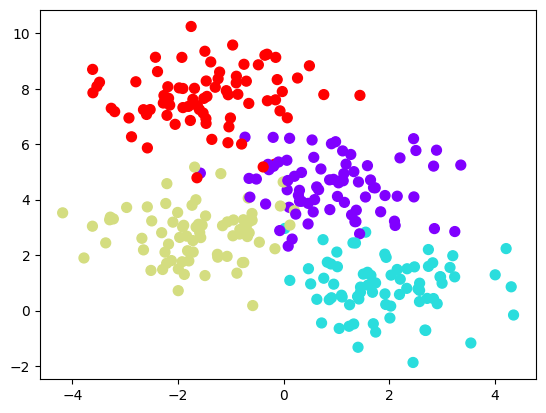

In [3]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');

/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64179/1795456885.py:20: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


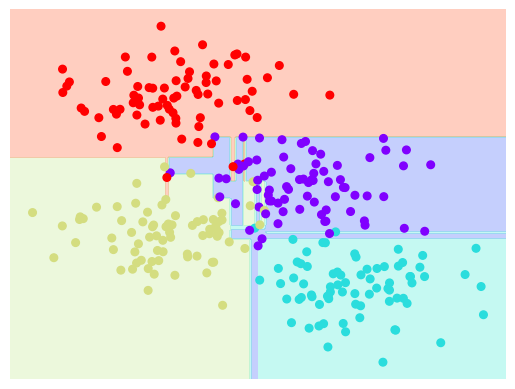

In [4]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
visualize_classifier(model, X, y);

Decision tree usually have an over-fitting problem.

/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64179/1795456885.py:20: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


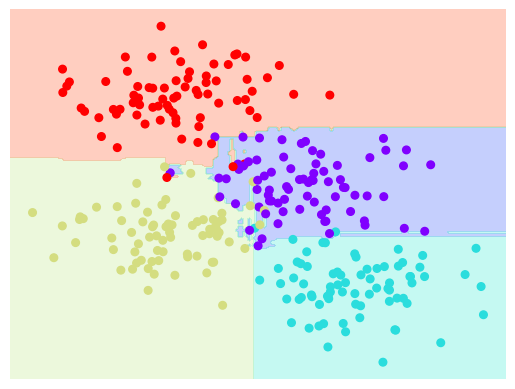

In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=1000, random_state=0)
# n_estimators = the number of trees in the forest.
# max_features = the number of features to consider when looking for the best split.
#   - default = 'auto' -> max_features=sqrt(n_features)
visualize_classifier(model, X, y);

We see that by averaging over 100 randomly perturbed models, we end up with an overall model that is much closer to our intuition about how the parameter space should be split.

## Example: Random Forest for Classifying Digits

Let's see how the random forest classifier can be used to classify the hand-written digits data.

In [6]:
from sklearn.datasets import load_digits
digits = load_digits()

In [7]:
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [8]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [9]:
digits.target[0]

np.int64(0)

In [10]:
digits.data.shape

(1797, 64)

To remind us what we're looking at, we'll visualize the first few data points:

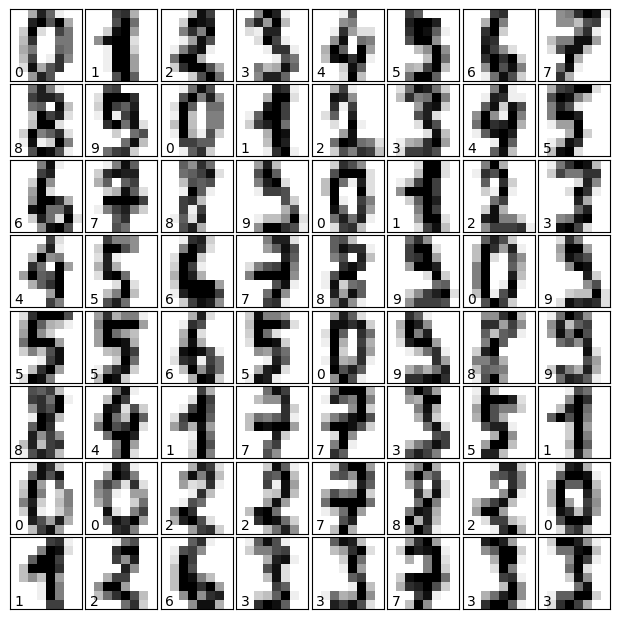

In [11]:
# set up the figure
fig = plt.figure(figsize=(6, 6))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# plot the digits: each image is 8x8 pixels
for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')

    # label the image with the target value
    ax.text(0, 7, str(digits.target[i]))

We can quickly classify the digits using a random forest as follows:

In [12]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data, digits.target,
                                                random_state=0)
model = RandomForestClassifier(n_estimators=1000)
model.fit(Xtrain, ytrain)
ypred = model.predict(Xtest)

In [13]:
ypred_prob = model.predict_proba(Xtest)

In [14]:
ytest[0]

np.int64(2)

In [15]:
ypred_prob[0]

array([0.004, 0.019, 0.85 , 0.048, 0.004, 0.013, 0.   , 0.017, 0.037,
       0.008])

In [16]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest, ypred)

0.98

We can take a look at the classification report for this classifier:

In [17]:
from sklearn import metrics
print(metrics.classification_report(ypred, ytest))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        38
           1       0.98      0.98      0.98        43
           2       0.98      1.00      0.99        43
           3       0.98      0.98      0.98        45
           4       0.97      1.00      0.99        37
           5       0.98      0.96      0.97        49
           6       1.00      1.00      1.00        52
           7       1.00      0.96      0.98        50
           8       0.94      0.98      0.96        46
           9       0.98      0.98      0.98        47

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



And for good measure, plot the confusion matrix:

Text(98.22222222222221, 0.5, 'predicted label')

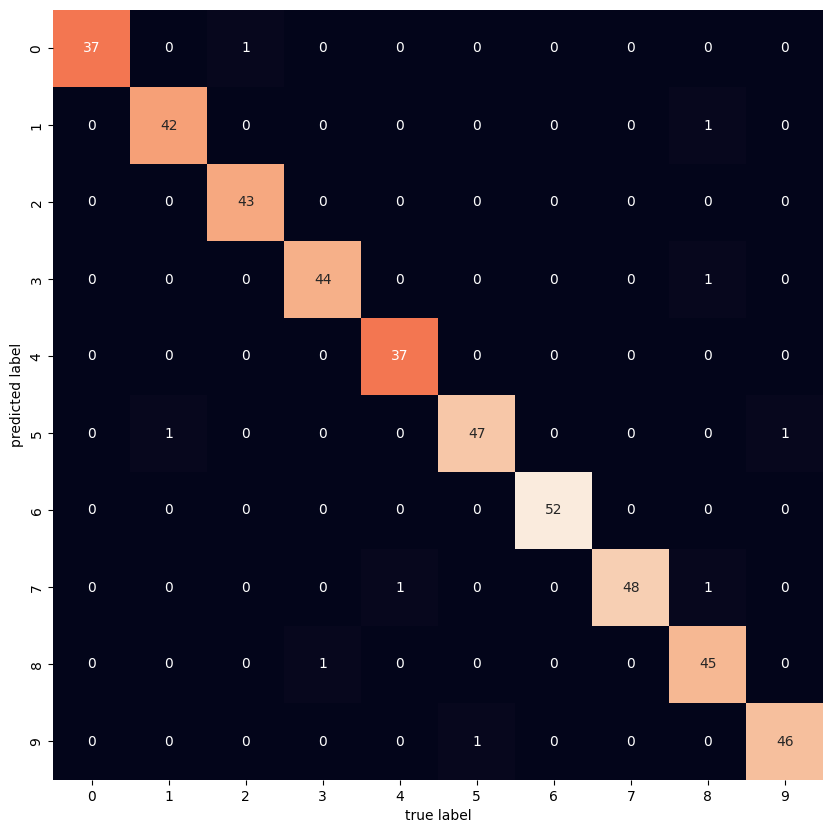

In [18]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, ypred)
plt.figure(figsize=(10, 10))
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('predicted label')

In [19]:
digits.data[19]

array([ 0.,  0.,  6., 14.,  4.,  0.,  0.,  0.,  0.,  0., 11., 16., 10.,
        0.,  0.,  0.,  0.,  0.,  8., 14., 16.,  2.,  0.,  0.,  0.,  0.,
        1., 12., 12., 11.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 11.,  3.,
        0.,  0.,  0.,  0.,  0.,  0.,  5., 11.,  0.,  0.,  0.,  1.,  4.,
        4.,  7., 16.,  2.,  0.,  0.,  7., 16., 16., 13., 11.,  1.])

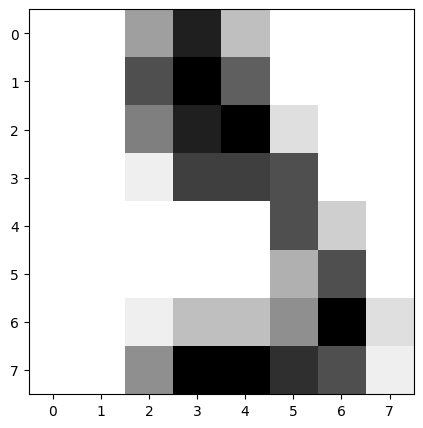

In [20]:
fig = plt.figure(figsize=(5, 5))
plt.imshow(digits.images[19], cmap=plt.cm.binary, interpolation='nearest')

In [21]:
digits.target[19]

np.int64(9)

In [22]:
result = model.predict(digits.data[19].reshape(1, 64))
result

array([9])

We find that a simple, untuned random forest results in a very accurate classification of the digits data.

## Random Forest Regression

Random forests can also be made to work in the case of regression (that is, continuous rather than categorical variables). The estimator to use for this is the ``RandomForestRegressor``, and the syntax is very similar to what we saw earlier.

Consider the following data, drawn from the combination of a fast and slow oscillation:

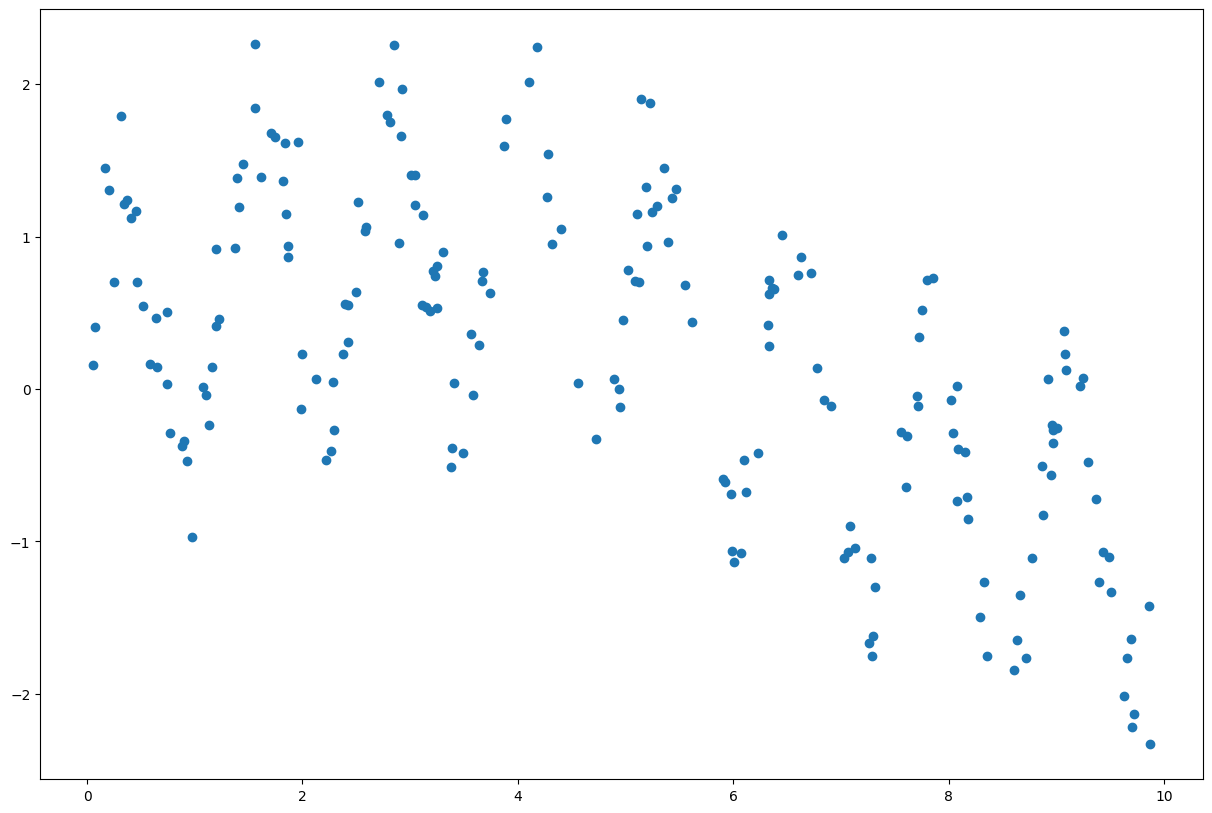

In [23]:
rng = np.random.RandomState(42)
x = 10 * rng.rand(200)

def model(x, sigma=0.3):
    fast_oscillation = np.sin(5 * x)
    slow_oscillation = np.sin(0.5 * x)
    noise = sigma * rng.randn(len(x))

    return slow_oscillation + fast_oscillation + noise

y = model(x)
plt.figure(figsize=(15, 10))
plt.scatter(x, y);

Using the random forest regressor, we can find the best fit curve as follows:

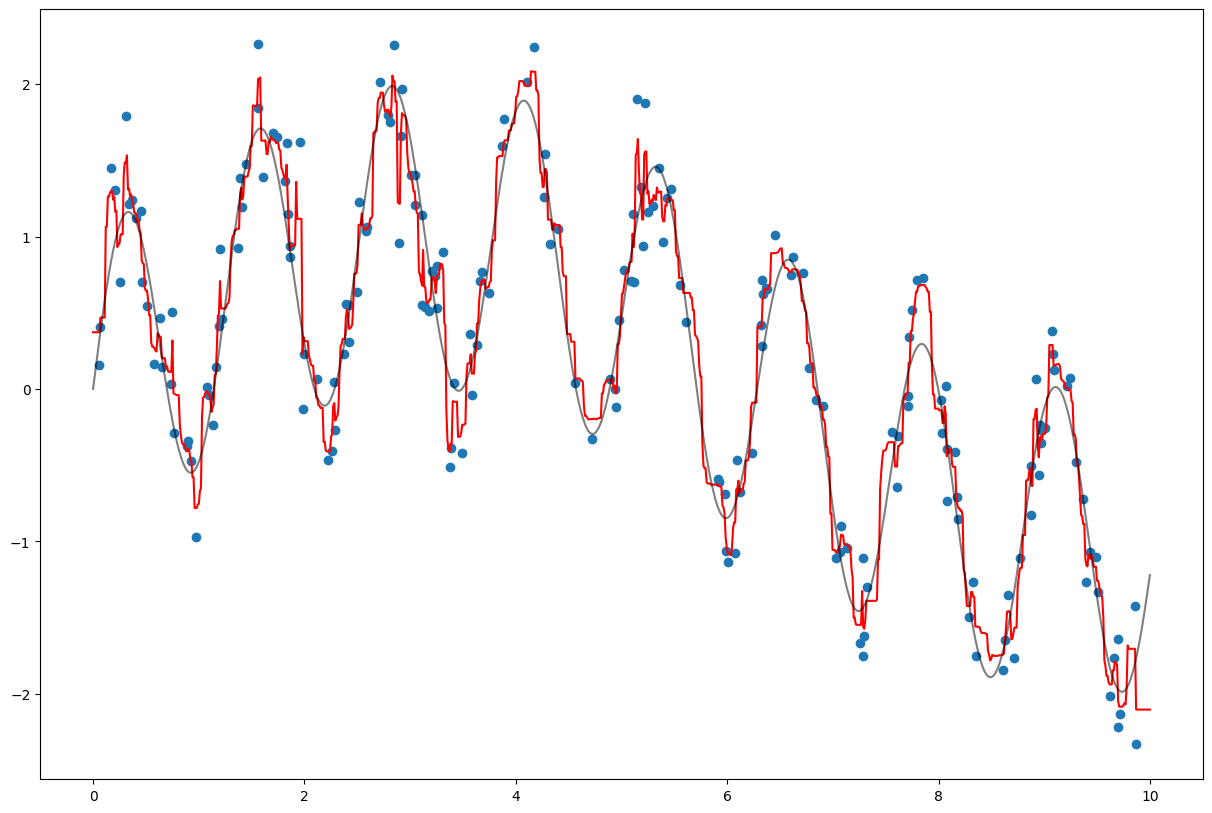

In [24]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor(200)
forest.fit(x[:, None], y)

xfit = np.linspace(0, 10, 1000)
yfit = forest.predict(xfit[:, None])
ytrue = model(xfit, sigma=0)

plt.figure(figsize=(15, 10))
plt.scatter(x, y)
plt.plot(xfit, yfit, '-r');
plt.plot(xfit, ytrue, '-k', alpha=0.5);

### Regression Tree
**Let’s see an example**

Let's say that we have developed a new drug to cure COVID-19.

However, we do not know the optimal dosage.

So, we conduct a clinical trial to collect data on the drug's effectiveness.

Credit: [Regression Trees, Clearly Explained!!!](https://www.youtube.com/watch?v=g9c66TUylZ4)

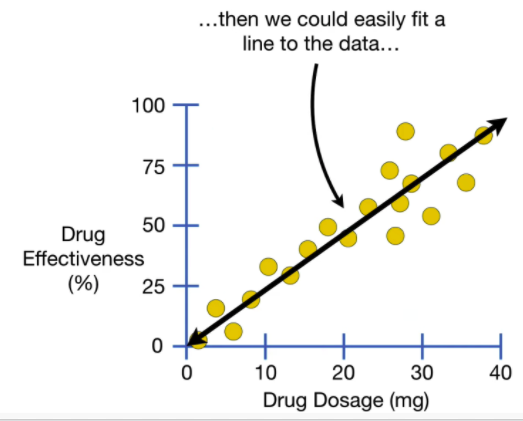

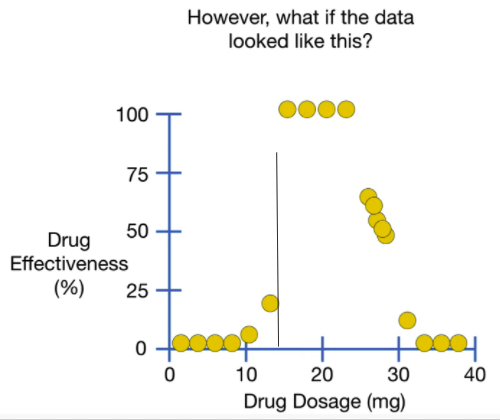

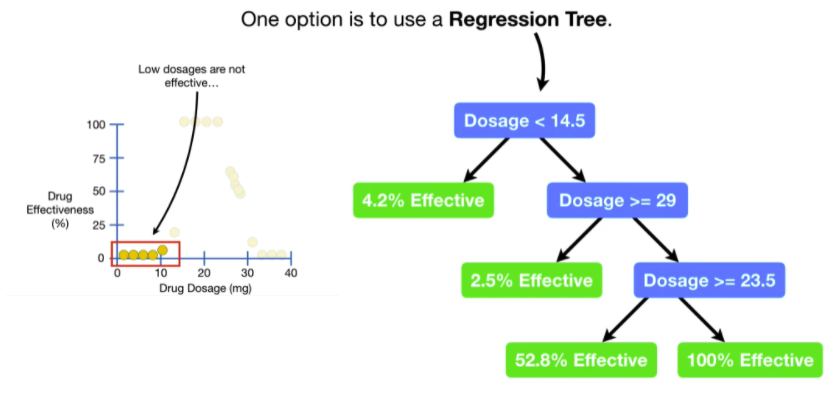

## Summary of Random Forests

Random forests are a powerful method with several advantages:

- Both training and prediction are very fast, because of the simplicity of the underlying decision trees. In addition, both tasks can be straightforwardly parallelized, because the individual trees are entirely independent entities.
- The multiple trees allow for a probabilistic classification: a majority vote among estimators gives an estimate of the probability (accessed in Scikit-Learn with the ``predict_proba()`` method).
- The nonparametric model is extremely flexible, and can thus perform well on tasks that are under-fit by other estimators.

A primary **disadvantage** of random forests is that the results are not easily interpretable: that is, if you would like to draw conclusions about the *meaning* of the classification model, random forests may not be the best choice.